# MATH50003 (2025–26)
# Lab 9: V.3 Discrete Convolutions and VI.1 Orthogonal Polynomials

Here we explore the practical implementation of discrete convolutions using
the FFT, which achieves $O(n \log n)$ complexity, which is a notable improvement
over the $O(n^2)$ complexity of a direct matrix-vector product using the formulation as a
circulant matrix.  We also explore experimentally the connection to random numbers, in particular,
how discrete convolutions give us the probabilities of the (periodic) addition of two random variables.

For orthogonal polynomials we introduce the basic family of Chebyshev polynomials. We see how properties
such as three-term recurrences can be used to efficiently compute them
in $O(n)$ operations without the need for calling trigonometric functions.
We also see how they give a very robust scheme for interpolation, and how we can differentiate by a relationship with a second kind of Chebyshev polynomials.

**Learning Outcomes**

Mathematical knowledge:

1. Using the FFT to compute convolutions.
2. The relationship between  convolutions and addition of random variables.
3. Convergence and stability of Chebyshev interpolation.
4. Differentiation via Chebyshev expansions.

Coding knowledge:

1. Using `fft` to compute convolutions.
2. Sampling random numbers with a specified probability via `sample`.
3. Evaluating 3-term recurrences.

In [9]:
using FFTW, StatsBase, Plots, Test

## V.3 Convolutions

We saw in lectures that discrete convolutions, circulant matrices, and the FFT are intrinsically linked. In particular, we can recast a discrete convolution defined via
$$y_k = 𝐚 ⋆ 𝐛 = \sum_{j=0}^{n-1}  a_{k-j} b_j$$
where
$$
𝐚 = \begin{bmatrix} a_0 \\ ⋮\\ a_{n-1}\end{bmatrix},\qquad 𝐛 = \begin{bmatrix} b_0 \\ ⋮\\ b_{n-1}\end{bmatrix}
$$
and we use the convention that $a_{-j} = a_{n-j}$. Here is a simple implementation using `mod` to handle the wrap-around:

In [10]:
function periodicconv(𝐚, 𝐛)
    n = length(𝐚)
    y = zeros(eltype(𝐚), n)
    for k in 1:n
        for j in 1:n
            y[k] += 𝐚[mod(k-j, n) + 1] * 𝐛[j]
        end
    end
    return y
end

𝐚 = [1,2,3]
𝐛 = [4,5,6]

@test periodicconv(𝐚, 𝐛) ≈ [1*4 + 3*5 + 2*6, 2*4 + 1*5 + 3*6, 3*4 +2*5 + 1*6]

Test Passed

In the notes we saw that the convolution can be related to the DFT. In particular, we have
$$
𝐚 ⋆ 𝐛 = Q_n^⋆diag(Q_n 𝐚)Q_n𝐛
$$
Here we verify this formula, recasting the diagonal multiplication as a broadcasted multiplication:

In [11]:
@test periodicconv(𝐚, 𝐛) ≈ ifft(fft(𝐚) .*  fft(𝐛))

Test Passed

Note the latter involves complex `Float64` arithmetic, hence its possible that integer results may not be exact.

We saw that convolutions could also be viewed as matrix-vector products with circulant matrices. In particular, we have
$$
C[𝐚] = \begin{bmatrix}
a_0 & a_{n-1} & ⋯ & a_2 & a_1 \\
a_1 & a_0 & a_{n-1}&  ⋯ & ⋮ \\
⋮ &  a_1 & a_0 & ⋱ &  ⋮  \\
a_{n-2}  & ⋯ & ⋱ & ⋱ & a_{n-1} \\
a_{n-1} & a_{n-2} & ⋯ & a_1 & a_0
\end{bmatrix}.
$$
We can implement a special type to represent circulant matrices where multiplication is overloaded to take advantage of the FFT:

----
**Problem 1** Complete the implementation of `Circulant`, which represents a circulant matrix.

In [16]:
struct Circulant <: AbstractMatrix{Float64}
    a::Vector{Float64} # represents the vector 𝐚
end

import Base: size, getindex, *
size(C::Circulant) = (length(C.a), length(C.a))
function getindex(C::Circulant, k::Int, j::Int)
    n = size(C)[1]
    C.a[mod(k-j,n) + 1]

end

function *(C::Circulant, x::Vector)
    real(ifft(fft(C.a) .*  fft(x)))
end


𝐚 = [1,2,3]
𝐛 = [4,5,6]
@test Circulant(𝐚) ≈ [1 3 2; 2 1 3; 3 2 1]
@test Circulant(𝐚) * 𝐛 isa Vector{Float64}
@test Circulant(𝐚) * 𝐛 ≈ periodicconv(𝐚, 𝐛)

Test Passed

----

The convolution over the real line has a natural interpretation in terms of the sum of independent random variables. In particular, if $X$ and $Y$ are independent random variables with probability density functions (PDFs) $f$ and $g$, then the PDF of the sum $Z = X + Y$ is given by the convolution
$$
(f ⋆ g)(x) = \int_{-\infty}^\infty f(x-y)g(y)dy.
$$
This property is also true for discrete random variables, provided that the addition is taken in a periodic sense.
That is,  consider a random variable $X$ which takes the values $0,…,n-1$ with probabilities $f_1,…,f_n$, which we can sample via the `sample` function from StatsBase.jl:

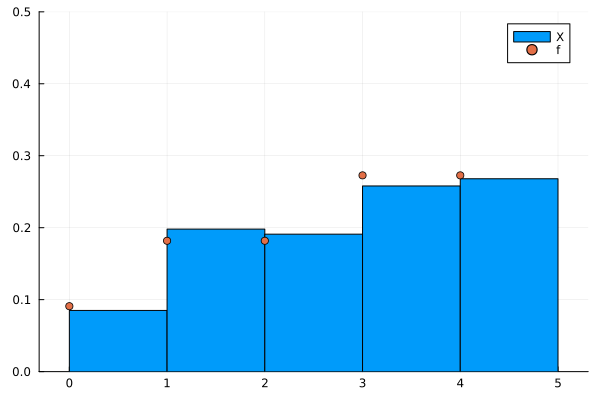

In [17]:
𝐟 = [1,2,2,3,3]; 𝐟 = 𝐟/sum(𝐟) # normalise the weights
n = length(𝐟)
X = sample(0:n-1, Weights(𝐟), 1000) # 1000 random samples
histogram(X; normalized=:probability, label="X") # plot a histogram, normalised to sum to 1
scatter!(0:n-1, 𝐟; ylims=(0,0.5), label="f") # desired weights

We can consider the addition with another random variable $Y$ which takes the same values but with probabilities $g_1,…,g_n$:

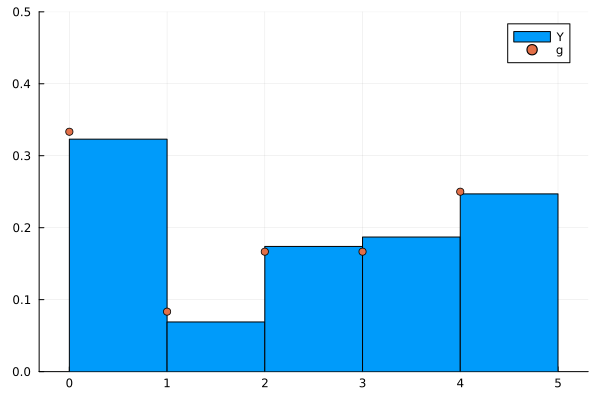

In [18]:
𝐠 = [4,1,2,2,3]; 𝐠 = 𝐠/sum(𝐠)
Y = sample(0:n-1, Weights(𝐠), 1000)
histogram(Y; normalized=:probability, label="Y")
scatter!(0:n-1, 𝐠; ylims=(0,0.5), label="g")

We now consider the addition of random variables. In this context, we
periodicise the value, that is, we consider the random variable
$$
X+Y \mod n.
$$
We won't prove it, but we can observe numerically that the distribution
is given precisely by the discrete convolution:

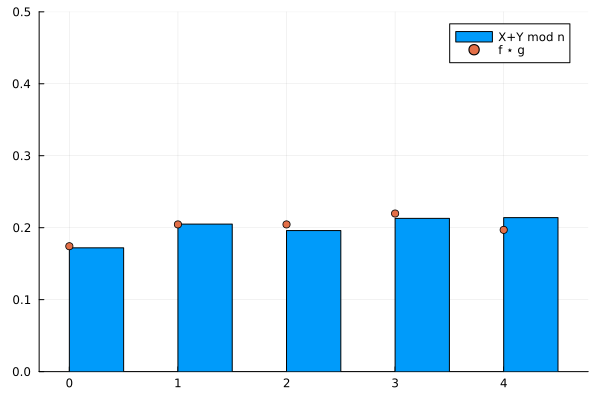

In [19]:
histogram(mod.(X+Y,n); normalized=:probability, label="X+Y mod n")
scatter!(0:n-1, periodicconv(𝐟,𝐠); ylims=(0,0.5), label="f ⋆ g")

**Problem 2(a)**  Consider a discrete periodic version of the Central Limit Theorem (CLT), that is, if we take $X_1,…,X_m$ to be independent random variables distributed according to $𝐟$, we want to study the distribution of $Z_m = X_1 + ⋯ + X_m \mod n$.
 Can you express the distribution in terms of a single FFT and inverse FFT?
Compare the predicted distribution with the empirical distribution obtained by sampling from $Z_m$ for $m = 10$.

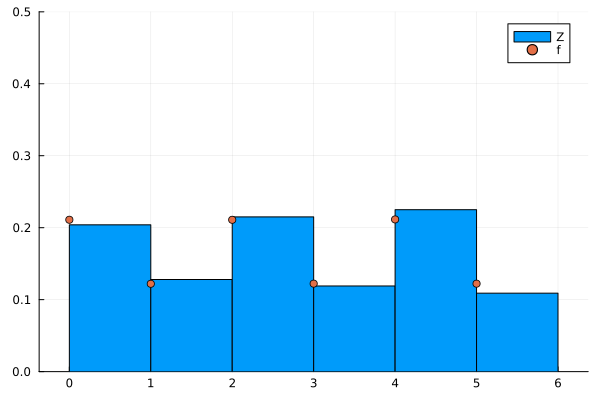

In [30]:
𝐟 = [1,2,50,3,40,1]; 𝐟 = 𝐟/sum(𝐟) # some arbitrary distribution
n = length(𝐟)
Z = zeros(Int,1000)
for k in 1:10
    X = sample(0:n-1, Weights(𝐟), 1000)
    Z = mod.(Z .+ X, n)
end
histogram(Z; normalized=:probability, label="Z")
pred = real(ifft(fft(𝐟).^10))
scatter!(0:n-1, pred; ylims=(0,0.5), label="f")

**Problem 2(b)** Use the connection to the DFT to plot the distrubtion of $Z_{100000}$.  What do you conjecture is the limitting distribution as $m → ∞$? Can you explain this in terms of absolute values of the DFT of $𝐟$?

In [ ]:
# TODO: what is the distribution with the sum of 100,000 samples of X?

**Problem 2(c)** Come up with a special distribution $𝐟$ that violates the CLT, that is, it tends to a different distribution. What feature does the DFT of $𝐟$ have that breaks the CLT?

In [ ]:
# TODO: come up with a special distribution that doesn't tend to the uniform distribution, and explain why in terms of the DFT.

## VI.1 Chebyshev Polynomials

We now turn to  Chebyshev polynomials are orthogonal on $[-1,1]$ with respect to $w(x) = 1/\sqrt{1-x^2}$.
They actually have an explicit formula as $T_n(x) = \cos n{\rm acos}\, x$. We can plot the first 5:

In [ ]:
g = range(-1,1,100) # plot grid
plot(g, cos.((0:4)' .* acos.(g)); label=["T₀" "T₁" "T₂" "T₃" "T₄"])

These satisfy a simple 3-term recurrence expressing $T_{n+1}(x)$ in terms of $T_n(x)$ and $T_{n-1}(x)$:
$$
\begin{align*}
x T_0(x) &= T_1(x), \\
x T_n(x) &= T_{n-1}(x)/2 + T_{n+1}(x)/2.
\end{align*}
$$
The recurrence gives us a way of computing $T_n(x)$ without the need for expensive trigonometric functions used in the explicit formula:

In [ ]:
function chebyshevt(n, x)
    Tₖ₋₁ = 1.0
    if n == 0
        return Tₖ₋₁
    end
    Tₖ = x
    for k = 1:n-1
        Tₖ,Tₖ₋₁ = 2x*Tₖ - Tₖ₋₁, Tₖ
    end
    Tₖ
end

x = 0.1
@test chebyshevt(10, x) ≈ cos(10*acos(x))

This is particularly useful if you need _all_ of $T_0(x),…,T_n(x)$, eg., to evaluate
a Chebyshev expansion, as we can save the values in a vector.

------

**Problem 3(a)** The previous code actually computes $T_0(x),…,T_n(x)$. Alter the implementation in the function `chebyshevt_vec(n, x)` to return a vector of these values in $O(n)$ operations.

In [ ]:
function chebyshevt_vec(n, x)
    T = zeros(typeof(x), n+1)
    # TODO: Populate T to be a vector of T₀(x),…,Tₙ(x) using the recurrence relationship

end

x = 0.1
@test chebyshevt_vec(10, x) ≈ [cos(k*acos(x)) for k=0:10]

 **Problem 3(a)** Use the previous function to implement `chebyshevvandermonde(n)` to return the $n × n$ Vandermonde-like matrix $V$ with entries $V_{jk} = T_{k-1}(x_j)$ where $x_j = \cos(\pi(j-1/2)/n)$ are the roots of $T_n$, in $O(n^2)$ operations.

In [ ]:
function chebyshevvandermonde(n)
    V = zeros(n, n)
    # TODO: return the n x n Vandermonde-like matrix V with entries V_{jk} = T_{k-1}(x_j) where x_j = cos(pi(j-1/2)/n) in O(n^2) operations.

    V
end


n = 15
x = cos.(π*((1:n) .- 1/2)/n) # Chebyshev points
V = chebyshevvandermonde(n)
V⁻¹ = 1/n * Diagonal([1; fill(2, n-1)]) * V' # we see in the notes that this is the inverse of V, so we can check our implementation against this formula
@test V * V⁻¹ ≈ I
c = V⁻¹ * exp.(x) # compute interpolation coefficients for exp
x = 0.1
T = chebyshevt_vec(n-1,x) # Chebyshev T
@test T'*c ≈ exp(x) # we have high-accuracy at any point in [-1,1]

**Problem 3(c)** Reconsider Lab 7, Q1. Interpolate $1/(4x^2+1)$ and $1/(25x^2 + 1)$ at the $n$ Chebyshev points $x_j = \cos(π(j-1/2)/n)$, plotting the solution at a grid of $1000$ evenly points for $n = 5, 20$, and $400$.
For which functions does it appear to converge? Do you think it is stable?

In [ ]:
# TODO: interpolate 1/(10x^2 + 1) and 1/(25x^2 + 1) at n Chebyshev spaced points, plotting both solutions evaluated at
# the plotting grid with 1000 points, for n = 5, 20, and 400.

------

In the problem sheet we consider the Chebyshev U polynomials defined by
$$
U_n(x) =  {\sin(n+1) θ \over \sin θ}
$$
which satisfy the recurrence relationship:
$$
\begin{align*}
x U_0(x) &= U_1(x)/2, \\
x U_n(x) &= {U_{n-1}(x) \over 2} + {U_{n+1}(x) \over 2}.
\end{align*}
$$
Here we adapt the techniques for the Chebyshev T polynomials to this second family, which hints that many properties apply for general orthogonal polynomials:

**Problem 4(a)** Use the recurrence relationship to evaluate $U_n(x)$ using only floating point arithmetic operations (i.e., no trigonometry).

In [ ]:
function chebyshevu(n, x)
    # TODO: Implement U_n(x) via the 3-term recurrence relationship

end

@test chebyshevu(10, 0.1) ≈ sin(11*acos(0.1))/sin(acos(0.1))

**Problem 4(b)** In the problem sheet we saw that $T_n'(x) = n U_{n-1}(x)$. Use this to approximate the
derivative of a function from samples at the Chebyshev points $x_j = \cos(π(j-1/2)/n)$.

In [ ]:
function chebyshevdifferentiation(f, n, x)
    # TODO: Use  the derivative relationship to approximate the derivative of f,
    # using a Chebyshev expansion of f up to degree n-1

end

@test chebyshevdifferentiation(cos, 15, 0.1) ≈ -sin(0.1)

**Problem 4(c)** For the function $f(x) = {\rm e}^x$ use the previous part
to approximate the derivative of $f$  at $x = 0$ for increasing choices of `n` up to 50.
What do you observe as $n → ∞$ when you plot the errors?
Can you achieve higher accuracy than central differences?

In [ ]:
# TODO: use chebyshevdifferentiation to approximate the derivative of f and observe the convergence

---

*This notebook was generated using [Literate.jl](https://github.com/fredrikekre/Literate.jl).*